In [1]:
# 05 - Feature Engineering
# Turns the cleaned dataset into a model-ready feature table -- does not train
# anything or split train/test (that's 06_Model_Preparation.ipynb). It:
#   1. Filters to actual AI users (only they have a Most_Used_Tool to predict)
#   2. Keeps the demographic/usage base features
#   3. Engineers new features from the multi-select columns (counts of tools
#      known, purposes, contexts, concerns)
#   4. Restricts the target to classes with enough samples to model
#   5. Saves the resulting feature table to data/processed/features/
#
# Columns intentionally excluded from features (kept only for reference):
# Respondent_ID, Timestamp, Comments, Feedback_Theme.

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/processed/AI_Tool_Survey_Cleaned.csv')
users = df[df['Is_AI_User']].copy()
print(f"AI users available: {len(users)}")


AI users available: 195


In [3]:
#  Restrict target to classes with enough samples 
tool_counts = users['Most_Used_Tool'].value_counts()
print(tool_counts)

MIN_SAMPLES_PER_CLASS = 5
valid_tools = tool_counts[tool_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
print(f"\nClasses kept (>= {MIN_SAMPLES_PER_CLASS} samples): {valid_tools}")

fe = users[users['Most_Used_Tool'].isin(valid_tools)].copy().reset_index(drop=True)
print(f"Rows kept: {len(fe)}")


Most_Used_Tool
ChatGPT               103
Claude                 56
Gemini                 28
Copilot                 4
ChatGPT and Gemini      1
Z.ai                    1
opencode                1
Manus AI                1
Name: count, dtype: int64

Classes kept (>= 5 samples): ['ChatGPT', 'Claude', 'Gemini']
Rows kept: 187


In [4]:
# Engineer count-based features from multi-select columns 
# Each multi-select column (semicolon-separated after cleaning) becomes a simple count e.g. how many AI tools a respondent knows, how many purposes they use AI for. These often carry more signal than the raw text lists.
def count_items(cell):
    if pd.isna(cell):
        return 0
    return len([x for x in cell.split(';') if x.strip()])

fe['Num_Tools_Known'] = fe['AI_Tools_Known'].apply(count_items)
fe['Num_Usage_Purposes'] = fe['Usage_Purpose'].apply(count_items)
fe['Num_Usage_Contexts'] = fe['Usage_Context'].apply(count_items)
fe['Num_Concerns'] = fe['Concerns'].apply(count_items)

fe[['Num_Tools_Known', 'Num_Usage_Purposes', 'Num_Usage_Contexts', 'Num_Concerns']].describe()


,Num_Tools_Known,Num_Usage_Purposes,Num_Usage_Contexts,Num_Concerns
count,187.000000,187.000000,187.000000,187.000000
mean,3.401070,4.122995,2.625668,2.304813
std,1.705336,2.127863,1.294730,1.319061
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,3.000000,2.000000,1.000000
50%,3.000000,4.000000,3.000000,2.000000
75%,5.000000,5.000000,3.000000,3.000000
max,9.000000,9.000000,6.000000,7.000000


In [5]:
#  Engineer a couple of derived flags 
fe['Is_Heavy_User'] = (fe['Usage_Frequency_Code'] >= 5).astype(int)   # once a day or more
fe['Has_Multiple_Concerns'] = (fe['Num_Concerns'] > 1).astype(int)
fe['Knows_Multiple_Tools'] = (fe['Num_Tools_Known'] > 1).astype(int)
fe[['Is_Heavy_User', 'Has_Multiple_Concerns', 'Knows_Multiple_Tools']].sum()


Is_Heavy_User            149
Has_Multiple_Concerns    121
Knows_Multiple_Tools     156
dtype: int64

In [6]:
# Assemble the final feature table 
feature_cols = [
    'Age_Group_Code', 'Gender', 'Occupation', 'Residence_Type',
    'Usage_Frequency_Code', 'Satisfaction_Code',
    'Num_Tools_Known', 'Num_Usage_Purposes', 'Num_Usage_Contexts', 'Num_Concerns',
    'Is_Heavy_User', 'Has_Multiple_Concerns', 'Knows_Multiple_Tools',
]
target_col = 'Most_Used_Tool'

feature_table = fe[['Respondent_ID'] + feature_cols + [target_col]].dropna(subset=feature_cols + [target_col])
feature_table = feature_table.reset_index(drop=True)
print(f"Final feature table: {feature_table.shape[0]} rows x {len(feature_cols)} features")
feature_table.head()


Final feature table: 186 rows x 13 features


,Respondent_ID,Age_Group_Code,Gender,Occupation,Residence_Type,Usage_Frequency_Code,Satisfaction_Code,Num_Tools_Known,Num_Usage_Purposes,Num_Usage_Contexts,Num_Concerns,Is_Heavy_User,Has_Multiple_Concerns,Knows_Multiple_Tools,Most_Used_Tool
0,R001,2,Female,Student,Semi - Urban,6.0,4.0,3,7,1,5,1,1,1,Claude
1,R002,2,Female,Student,Urban,6.0,4.0,3,4,3,4,1,1,1,ChatGPT
2,R003,2,Male,Student,Urban,6.0,5.0,5,4,4,1,1,0,1,Claude
3,R004,2,Male,Student,Rural,4.0,4.0,4,3,2,3,0,1,1,Claude
4,R005,2,Male,Student,Urban,4.0,4.0,2,4,2,1,0,0,1,ChatGPT


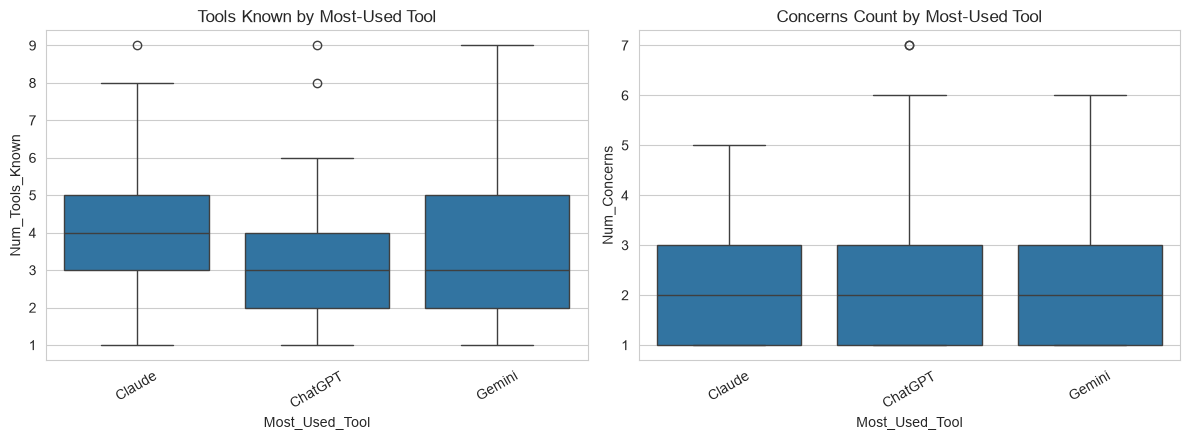

In [7]:
#  Diagram: Do the engineered features separate the classes?
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=feature_table, x='Most_Used_Tool', y='Num_Tools_Known', ax=axes[0])
axes[0].set_title('Tools Known by Most-Used Tool')
axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=feature_table, x='Most_Used_Tool', y='Num_Concerns', ax=axes[1])
axes[1].set_title('Concerns Count by Most-Used Tool')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


In [8]:
# Save the feature table 
out_dir = 'data/processed/features'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/Engineered_Features.csv'
feature_table.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Feature columns saved for downstream use: {feature_cols}")


Saved: data/processed/features/Engineered_Features.csv
Feature columns saved for downstream use: ['Age_Group_Code', 'Gender', 'Occupation', 'Residence_Type', 'Usage_Frequency_Code', 'Satisfaction_Code', 'Num_Tools_Known', 'Num_Usage_Purposes', 'Num_Usage_Contexts', 'Num_Concerns', 'Is_Heavy_User', 'Has_Multiple_Concerns', 'Knows_Multiple_Tools']
